In [1]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

In [2]:
df_main = pd.read_csv('../data/processed/oscar_tmdb_advanced_features.csv')
oscar_raw = pd.read_csv('../data/raw/the_oscar_award.csv')

In [3]:
best_picture_noms = oscar_raw[oscar_raw['category'].str.contains('PICTURE', na=False, case=False)]

In [4]:
best_picture_noms.head()

,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner
17,1927,1928,1,DIRECTING (Comedy Picture),DIRECTING (Comedy Picture),Lewis Milestone,Two Arabian Knights,True
18,1927,1928,1,DIRECTING (Comedy Picture),DIRECTING (Comedy Picture),Ted Wilde,Speedy,False
19,1927,1928,1,DIRECTING (Dramatic Picture),DIRECTING (Dramatic Picture),Frank Borzage,7th Heaven,True
20,1927,1928,1,DIRECTING (Dramatic Picture),DIRECTING (Dramatic Picture),Herbert Brenon,Sorrell and Son,False
21,1927,1928,1,DIRECTING (Dramatic Picture),DIRECTING (Dramatic Picture),King Vidor,The Crowd,False


In [5]:
bp_winners = best_picture_noms[best_picture_noms['winner'] == True]['film'].str.lower().dropna().unique()

In [6]:
df_main = df_main.copy()

df_main['is_best_picture'] = df_main['title'].str.lower().isin(bp_winners).astype(int)

In [7]:
df_main['is_best_picture'].sum().tolist()

71

In [8]:
x = df_main.select_dtypes(include='number').drop(columns=['is_oscar_winner', 'is_best_picture'],
                                                 errors='ignore').fillna(0)

y_best = df_main['is_best_picture']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y_best, test_size=0.2, random_state=42, stratify=y_best)

In [10]:
start_time = time.time()

estimator = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
selector = RFE(estimator, n_features_to_select=30, step=100)

x_train_rfe = selector.fit_transform(x_train, y_train)
x_test_rfe = selector.transform(x_test)

rfe_time = time.time() - start_time

rfe_time

5.9288740158081055

In [11]:
selected_features = x.columns[selector.get_support(indices=True)].tolist()

selected_features

['budget',
 'popularity',
 'revenue',
 'runtime',
 'vote_average',
 'vote_count',
 'genre_drama',
 'genre_history',
 'genre_war',
 'key_amnesia',
 'key_anti_semitism',
 'key_boston',
 'key_british_empire',
 'key_class_differences',
 'key_combat',
 'key_denmark',
 'key_film_history',
 'key_movie_poster',
 'key_post_traumatic_stress_disorder',
 'key_resistance',
 'key_slum',
 'key_speculative',
 'key_suspense',
 'key_suspicion',
 'key_travelling_circus',
 'key_tutor',
 'key_united_statesmexico_barrier',
 'key_vietnam',
 'director_oscar_rate',
 'avg_cast_oscar_rate']

In [12]:
weight = (y_train == 0).sum() / (y_train == 1).sum()

weight

np.float64(12.824561403508772)

In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=weight,
    random_state=42,
    n_jobs=-1
)

In [14]:
xgb_model.fit(x_train_rfe, y_train)
y_pred = xgb_model.predict(x_test_rfe)

In [15]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T

report_df.round(3)

Accuracy: 0.8883


,precision,recall,f1-score,support
0,0.945,0.934,0.940,183.000
1,0.250,0.286,0.267,14.000
accuracy,0.888,0.888,0.888,0.888
macro avg,0.597,0.610,0.603,197.000
weighted avg,0.895,0.888,0.892,197.000


In [16]:
y_probs = xgb_model.predict_proba(x_test_rfe)[:, 1]

custom_threshold = 0.45
y_pred_custom = (y_probs >= custom_threshold).astype(int)

In [17]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")

report_custom = pd.DataFrame(classification_report(y_test, y_pred_custom, output_dict=True)).T
report_custom.round(3)

Accuracy: 0.8934


,precision,recall,f1-score,support
0,0.955,0.929,0.942,183.000
1,0.316,0.429,0.364,14.000
accuracy,0.893,0.893,0.893,0.893
macro avg,0.635,0.679,0.653,197.000
weighted avg,0.910,0.893,0.901,197.000


In [18]:
selected_features = x.columns[selector.get_support()]

x_test_df = pd.DataFrame(x_test_rfe, columns=selected_features)

In [19]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(x_test_df)

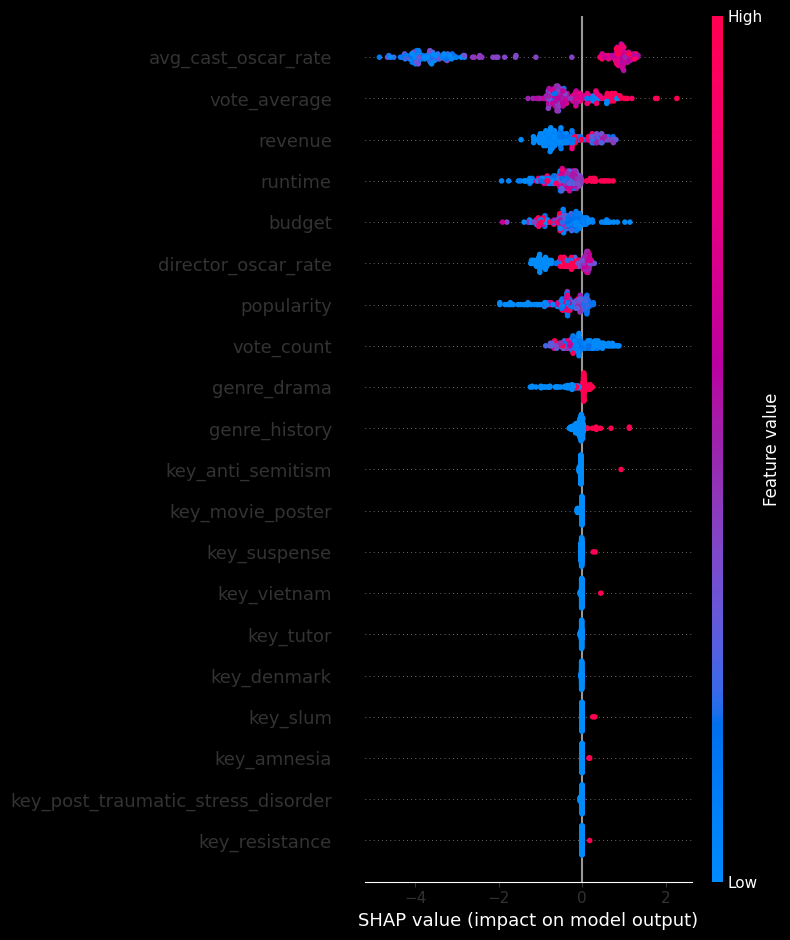

In [20]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test_df, show=False)
plt.tight_layout()
plt.show()

Waterfall plot for 'The Hurt Locker'



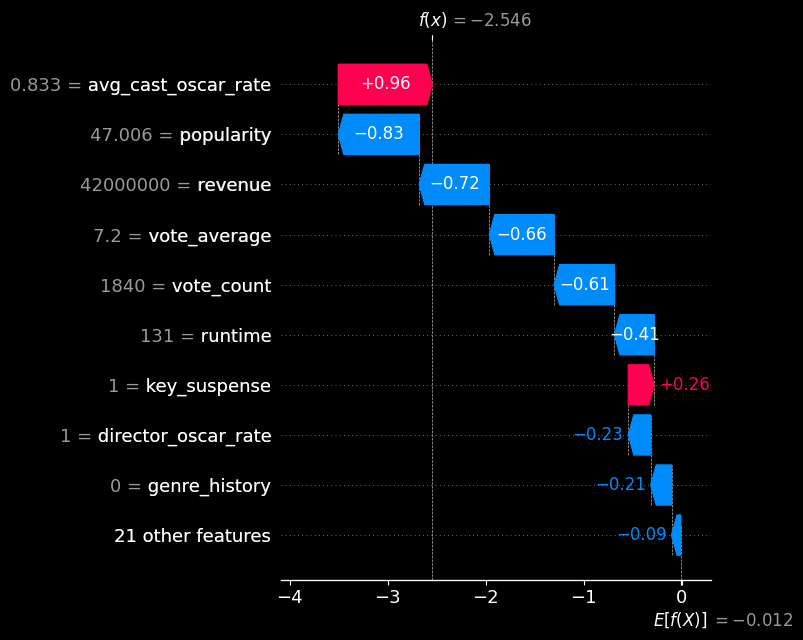

In [21]:
winner_positions = [i for i, val in enumerate(y_test) if val == 1]

if winner_positions:
    example_idx = winner_positions[0]
    real_title = df_main.loc[y_test.index[example_idx], 'title']

    print(f"Waterfall plot for '{real_title}'\n")

    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_values[example_idx], show=False)
    plt.tight_layout()
    plt.show()